# 🧠 Naive Bayes Classifier

## 📋 Core Concept
A **probabilistic classifier** based on **Bayes' Theorem** with a "naive" assumption of conditional independence between features.

---

## 🔬 Mathematical Foundation

### Bayes' Theorem
$$P(y|X) = \frac{P(X|y) \cdot P(y)}{P(X)}$$

Where:
- $P(y|X)$ = **Posterior probability** (what we want)
- $P(X|y)$ = **Likelihood** 
- $P(y)$ = **Prior probability**
- $P(X)$ = **Evidence** (normalizing constant)

### Classification Rule
$$\hat{y} = \arg\max_{y} P(y|X) = \arg\max_{y} P(X|y) \cdot P(y)$$

### The "Naive" Assumption
Features are **conditionally independent** given the class:
$$P(X|y) = P(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} P(x_i|y)$$

---

## 🎯 Algorithm Steps

1. **Calculate Prior**: $P(y_k) = \frac{\text{count}(y_k)}{N}$

2. **Calculate Likelihood**: $P(x_i|y_k)$ for each feature

3. **Apply Naive Assumption**: $P(X|y_k) = \prod_{i=1}^{n} P(x_i|y_k)$

4. **Predict**: $\hat{y} = \arg\max_{k} P(y_k) \prod_{i=1}^{n} P(x_i|y_k)$

---

## 🔄 Types of Naive Bayes

### 1. **Gaussian NB** (Continuous features)
$$P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_{y}^2}} \exp\left(-\frac{(x_i-\mu_y)^2}{2\sigma_{y}^2}\right)$$

### 2. **Multinomial NB** (Count data)
$$P(x_i|y) = \frac{N_{yi} + \alpha}{N_y + \alpha n}$$
- Good for: **Text classification**, **word counts**

### 3. **Bernoulli NB** (Binary features)
$$P(x_i|y) = P(i|y)x_i + (1-P(i|y))(1-x_i)$$
- Good for: **Binary text features** (word presence/absence)

---

## ⚡ Key Advantages

- **Simple & Fast**: Linear time complexity $O(n \cdot d)$
- **Handles Missing Data**: Can work with incomplete features
- **Good Baseline**: Often surprisingly effective
- **Probabilistic Output**: Gives confidence scores
- **Small Data Friendly**: Works well with limited training data

---

## ⚠️ Key Limitations

- **Independence Assumption**: Features are rarely truly independent
- **Zero Probability Problem**: Unseen feature combinations get 0 probability
- **Categorical Bias**: Assumes features contribute equally

---

## 🛠️ Practical Considerations

### Laplace Smoothing (Add-1 Smoothing)
$$P(x_i|y) = \frac{\text{count}(x_i, y) + \alpha}{\text{count}(y) + \alpha \cdot |V|}$$
- **Purpose**: Avoid zero probabilities
- **Common**: $\alpha = 1$ (Laplace), $\alpha = 0.5$ (Jeffreys)

### Log Probabilities
Use $\log P(y|X)$ to avoid **numerical underflow**:
$$\log P(y|X) = \log P(y) + \sum_{i=1}^{n} \log P(x_i|y)$$

---

## 🎯 Best Use Cases

- **Text Classification** (spam detection, sentiment analysis)
- **Medical Diagnosis** (symptom → disease)
- **Real-time Prediction** (low latency requirements)
- **Baseline Model** (quick benchmark for complex models)

---

## 💡 Key Insight
Despite the "naive" assumption being violated in practice, Naive Bayes often performs surprisingly well because:
- Classification only needs **relative probabilities**, not absolute
- **Bias-variance tradeoff**: Strong assumptions reduce variance

### 🧠 Naive Bayes Classifier 

---

## 🔹 What Is Naive Bayes?

Naive Bayes is a **probabilistic classifier** based on **Bayes’ Theorem**, with a **naive assumption** that **features are conditionally independent given the class**.

---

## 🔸 Bayes’ Theorem

For an instance $x = (x_1, x_2, ..., x_n)$, Bayes’ theorem says:

```math
P(y \mid x) = \frac{P(x \mid y) \cdot P(y)}{P(x)}
```

In classification, we care about:

```math
\hat{y} = \arg\max_y P(y \mid x) = \arg\max_y P(x \mid y) \cdot P(y)
```

(since $P(x)$ is the same for all classes, we ignore it in argmax)

---

## 🔹 Naive Assumption

Assume features are **independent given the class**:

```math
P(x \mid y) = \prod_{i=1}^n P(x_i \mid y)
```

So now:

```math
\hat{y} = \arg\max_y P(y) \prod_{i=1}^n P(x_i \mid y)
```

This is what makes Naive Bayes **very fast** and **scalable**, even with lots of features.

---

## 🔸 Types of Naive Bayes

| Variant            | Use Case                                    | Assumption                          |
| ------------------ | ------------------------------------------- | ----------------------------------- |
| **Gaussian NB**    | Continuous features (e.g., real values)     | Features follow normal distribution |
| **Multinomial NB** | Count features (e.g., word counts)          | Features are discrete, non-negative |
| **Bernoulli NB**   | Binary features (e.g., word present/absent) | Features are 0/1                    |

---

## 🔸 Gaussian Naive Bayes (Most Common)

For real-valued features:

```math
P(x_i \mid y) = \frac{1}{\sqrt{2\pi \sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)
```

* $\mu_y$, $\sigma_y^2$: estimated from training data for each class

---

## 🔹 Training Naive Bayes

During training:

1. Estimate **prior probabilities** $P(y)$
2. Estimate **likelihood** $P(x_i \mid y)$ for each feature

Training is **extremely fast**: no optimization needed — just compute means, variances, or frequencies.

---

## 🔹 Prediction Rule

```math
\hat{y} = \arg\max_y P(y) \prod_{i=1}^{n} P(x_i \mid y)
```

To avoid underflow from multiplying many small numbers, we use **log-probabilities**:

```math
\hat{y} = \arg\max_y \log P(y) + \sum_{i=1}^{n} \log P(x_i \mid y)
```

---

## 🔸 Scikit-learn Example

```python
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=100, n_features=4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = GaussianNB()
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))
```

---

## 🔹 Advantages

✅ Extremely fast
✅ Works well on **high-dimensional** data (e.g., text)
✅ Requires **very little training data**
✅ Easy to implement

---

## 🔸 Limitations

❌ **Independence assumption** is rarely true
❌ Performs poorly if features are **highly correlated**
❌ Gaussian NB assumes **normal distribution**

---

## 🧠 Summary Table

| Property            | Naive Bayes                         |
| ------------------- | ----------------------------------- |
| Type                | Probabilistic                       |
| Learning Type       | Supervised                          |
| Speed               | Very fast                           |
| Assumption          | Feature independence given class    |
| Best For            | Text classification, spam filtering |
| Handles Multiclass? | ✅ Yes                               |

---



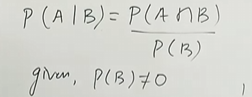